# 09 — Reading events

Notebook 02 is about `grand.dataio`, which reads and writes the trees. This
one is about `grand.aoi`, which sits on top of it, and the difference is worth
stating plainly before any code:

**`dataio` gives you branches. `aoi` gives you an event.**

Read a `TEfield` directly and you get parallel arrays — a list of traces, a
list of detector-unit ids, a list of second and nanosecond counts — and it is
your job to keep them lined up and to work out what "the same moment" means
across units that did not start recording together. `aoi` does that join and
hands back an `Event`: antennas with positions, traces on one common clock,
and the shower that produced them.

That convenience has a price, and this notebook is as much about the price as
the convenience. One trap in particular will bite anyone who writes the
obvious thing, and it is in section 3.

## 1. Opening a directory

`EventList` takes a directory in the sim2root layout — one tree per file — and
indexes the events across it.

In [1]:
import contextlib
import io
import logging

import numpy as np
import matplotlib.pyplot as plt

# ROOT reports every branch a file does not carry; those lines would sit
# between each command below and its answer.
logging.getLogger("grand").setLevel(logging.ERROR)

from grand.aoi.event_list import EventList

DIR = "../sim2root/Common/sim_Xiaodushan_20221026_000000_RUN0_CD_ZHAireS_0000"

events = EventList(DIR)
print("events indexed: %d" % len(events.event_list))
print("first four (event, run): %s" % (events.event_list[:4],))
print("last:                    %s" % (events.event_list[-1],))

events indexed: 10
first four (event, run): [(13020, 0), (5388, 0), (6914, 0), (20604, 0)]
last:                    (23098, 0)


Iterating gives an `Event`. Everything on it is an object rather than an index
into a parallel array.

In [2]:
event = next(iter(events))

print()
print("run %s, event %s" % (event.run_number, event.event_number))
print("  antennas %d   efields %d   voltages %d"
      % (len(event.antennas), len(event.efields), len(event.voltages)))

Run information loaded.


Voltage information loaded.
Efield information loaded.
Simulated shower information loaded.

run 0, event 13020
  antennas 7   efields 7   voltages 7


Four lines of narration arrived before the answer. `Event.fill_event_from_trees`
announces each tree it loads with a bare `print`, once per event, so a
ten-event loop prints forty lines before its first result. They are not log
records — `logging.getLogger("grand").setLevel(...)`, which quietens ROOT
elsewhere in these notebooks, does not reach them.

Nothing in the library turns them off, so the rest of this notebook silences
them at the call site. Worth knowing before you wonder why a script that reads
a thousand events produces four thousand lines of chatter.

In [3]:
@contextlib.contextmanager
def quiet():
    """Swallows aoi's per-event narration for the duration of the block."""
    with contextlib.redirect_stdout(io.StringIO()):
        yield


with quiet():
    event = next(iter(EventList(DIR)))

antenna = event.antennas[0]
position = np.ravel([antenna.position.x, antenna.position.y, antenna.position.z])
print("antenna[0]: du %s at (%.1f, %.1f, %.1f) m"
      % (antenna.id, position[0], position[1], position[2]))

efield = event.efields[0]
print("efield[0] : %d points, peak %.1f uV/m"
      % (efield.n_points, np.abs(efield.trace.x).max()))

antenna[0]: du 239 at (-4330.1, 3500.0, 72.5) m
efield[0] : 2048 points, peak 26.6 uV/m


`position.x` is a length-1 array rather than a float — the coordinate classes
carry arrays throughout — so `np.ravel` is usually what you want before
printing or comparing.

## 2. The trap: there is only ever one Event

`EventList` reuses a single `Event` and refills it on each step. That is
intended rather than accidental — `tests/aoi/test_event_list.py` pins the
behaviour — but it means the obvious way to collect events silently gives you
the same one, several times over.

In [4]:
with quiet():
    collected = [event for event in EventList(DIR)]

print("collected          : %d" % len(collected))
print("distinct objects   : %d" % len({id(event) for event in collected}))
print("event numbers held : %s" % [int(e.event_number) for e in collected[:5]])
print()
print("Every entry is the same object, holding the event the loop ended on:")
print("  last in the index: %s" % (EventList(DIR).event_list[-1],))

collected          : 10
distinct objects   : 1
event numbers held : [23098, 23098, 23098, 23098, 23098]

Every entry is the same object, holding the event the loop ended on:


  last in the index: (23098, 0)


Ten entries, one object, and every one of them reports the last event in the
directory.

The fix is to take what you need **inside** the loop rather than keeping the
event itself. Anything you hold on to — a trace, an antenna, a shower — is a
reference into an object that is about to be overwritten, so copy the numbers
out, not the container.

In [5]:
with quiet():
    summary = []
    for event in EventList(DIR):
        peak = max(float(np.abs(e.trace.x).max()) for e in event.efields)
        summary.append((int(event.event_number), len(event.antennas), peak))

print("%-10s %-10s %s" % ("event", "antennas", "peak |Ex| (uV/m)"))
for number, n_ant, peak in summary:
    print("%-10d %-10d %8.1f" % (number, n_ant, peak))

event      antennas   peak |Ex| (uV/m)
13020      7             147.6
5388       157           878.8
6914       63            242.2
20604      48            988.5
23832      7              34.6
20292      14            568.7
8550       236           619.5
18438      246           529.0
12648      7            2364.6
23098      212           214.0


Ten different events now, with the antenna multiplicity varying from a handful
to a couple of hundred.

## 3. One clock for the whole event

This is what `aoi` gives you that the trees do not. Detector units trigger at
different absolute times, so their traces do not correspond sample for sample.
`aoi` reads each unit's start time and builds `t_vector`, a time axis in
nanoseconds relative to the earliest unit in the event.

In [6]:
with quiet():
    event = next(iter(EventList(DIR)))

print("%-6s %-22s %14s %14s" % ("du", "start (ns, epoch)", "t_vector[0]", "peak at"))
for e in event.efields:
    t = np.ravel(e.t_vector)
    peak_at = t[np.argmax(np.abs(np.ravel(e.trace.x)))]
    print("%-6s %-22s %11.1f ns %11.1f ns"
          % (e.du_id, e.t0.astype("int64"), t[0], peak_at))

du     start (ns, epoch)         t_vector[0]        peak at
239    200854920000005703          9431.0 ns     13263.0 ns
247    200854920000003357          7085.0 ns      9133.0 ns
254    200854920000000883          4611.0 ns      5427.0 ns
260    200854920000000871          4599.0 ns      7075.0 ns
261    200854919999998651          2379.0 ns      4103.0 ns
267    200854919999996284            12.0 ns      2844.0 ns
272    200854919999996272             0.0 ns       798.0 ns


The units are spread over about nine microseconds of arrival time. Sample 0 of
one trace is not sample 0 of another, and any comparison that ignores that is
comparing different instants.

With a common axis, sampling the whole array at one moment is a single
call.

In [7]:
instant = 4000.0                       # ns on the event's own clock
values = event.get_voltage_at_time(instant)
print("get_voltage_at_time(%.0f) -> %s   (unit, arm)" % (instant, np.shape(values)))

# The analytic envelope is available the same way, and is usually what you want
# for a peak search: it does not depend on where a zero crossing happened to fall.
envelope = event.get_hilbert_voltage_at_time(instant)
print("get_hilbert_voltage_at_time      -> %s" % (np.shape(envelope),))
print()
e = event.efields[0]
print("du %s: trace peak %.1f, envelope peak %.1f uV/m"
      % (e.du_id, np.abs(e.trace.x).max(), np.abs(e.hilbert_trace.x).max()))

get_voltage_at_time(4000) -> (7, 3)   (unit, arm)
get_hilbert_voltage_at_time      -> (7, 3)

du 239: trace peak 26.6, envelope peak 31.2 uV/m


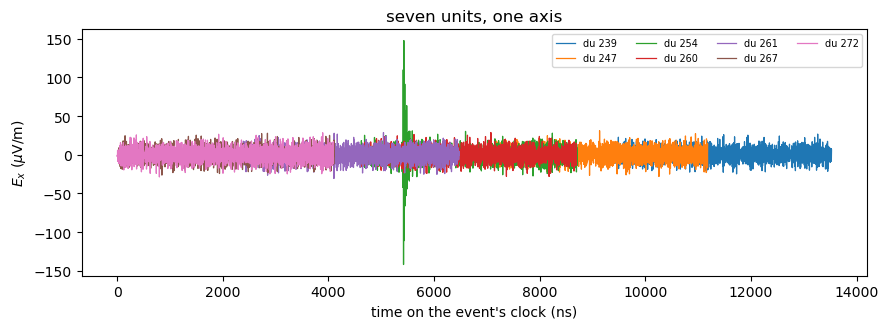

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.4))
for e in event.efields:
    ax.plot(np.ravel(e.t_vector), np.ravel(e.trace.x), lw=0.9, label="du %s" % e.du_id)
ax.set_xlabel("time on the event's clock (ns)")
ax.set_ylabel(r"$E_x$ ($\mu$V/m)")
ax.set_title("seven units, one axis")
ax.legend(fontsize=7, ncol=4); fig.tight_layout()

## 4. Which analysis level are you reading?

Notebook 02 records that with an L0 and an L1 file side by side, the bare
`directory.tefield` follows the **highest** level. `aoi` inherits that, and the
consequence is larger than it sounds, because the two levels are not the same
data under a different name.

In [9]:
from grand.dataio.event_trees import TEfield

for level, name in ((0, "efield_5388-23832_L0_0000.root"),
                    (1, "efield_5388-23832_L1_0000.root")):
    tree = TEfield(_file_name="%s/%s" % (DIR, name))
    tree.get_event(13020, 0)
    trace = np.asarray(tree.trace, dtype=np.float64)
    print("L%d  %-16s peak %7.1f uV/m   analysis_level %s"
          % (level, str(trace.shape), np.abs(trace).max(), tree.analysis_level))

L0  (7, 3, 8192)     peak   669.5 uV/m   analysis_level 0
L1  (7, 3, 2048)     peak   147.6 uV/m   analysis_level 1


L0 is the raw simulation at 0.5 ns; L1 is band-limited and resampled to 2 ns.
Four times fewer samples, and a peak lower by a factor of about four and a
half. The peak is the filter's doing rather than the resampling's: restricting
a sharp pulse to a narrower band spreads it in time and lowers its maximum.
Ask for "the efield" in a directory holding both and you get L1, without being
told.

Say which you want.

In [10]:
for level in (0, 1, None):
    with quiet():
        first = next(iter(EventList(DIR, tefield_level=level)))
    n = len(np.ravel(first.efields[0].trace.x))
    print("tefield_level=%-5s -> %5d samples per trace" % (level, n))
print()
print("None is not 'the default level'; it is 'whichever is highest'.")

tefield_level=0     ->  8192 samples per trace


tefield_level=1     ->  2048 samples per trace


tefield_level=None  ->  2048 samples per trace

None is not 'the default level'; it is 'whichever is highest'.


## 5. Closing the loop

Everything above is convenience, and convenience is worth nothing if the
numbers moved on the way through. So read the same event through both layers
and compare.

In [11]:
with quiet():
    event = next(iter(EventList(DIR)))

through_aoi = np.array([[np.ravel(e.trace.x), np.ravel(e.trace.y), np.ravel(e.trace.z)]
                        for e in event.efields])
ids_aoi = [e.du_id for e in event.efields]

tree = TEfield(_file_name="%s/efield_5388-23832_L1_0000.root" % DIR)
tree.get_event(event.event_number, event.run_number)
through_dataio = np.asarray(tree.trace, dtype=np.float64)

print("aoi    %s  du ids %s" % (through_aoi.shape, ids_aoi))
print("dataio %s  du ids %s" % (through_dataio.shape, list(tree.du_id)))
print()
print("same order         : %s" % (ids_aoi == list(tree.du_id)))
print("largest difference : %g" % np.abs(through_aoi - through_dataio).max())

aoi    (7, 3, 2048)  du ids [239, 247, 254, 260, 261, 267, 272]
dataio (7, 3, 2048)  du ids [239, 247, 254, 260, 261, 267, 272]

same order         : True
largest difference : 0


Identical, and in the same order. `aoi` re-presents the traces; it does not
touch them.

That the comparison is against L1 rather than L0 is section 4 restated. Had it
been made against the L0 file it would have disagreed by a factor of four in
length, and the layer would have looked broken when it was the level that
differed.

## 6. Showers: there are two, and one is often absent

In [12]:
with quiet():
    event = next(iter(EventList(DIR)))

print("event.shower    : %s" % type(event.shower).__name__)
print("event.simshower : %s" % type(event.simshower).__name__)
print()
shower = event.simshower
print("zenith   %.2f deg" % np.ravel(shower.zenith)[0])
print("azimuth  %.2f deg" % np.ravel(shower.azimuth)[0])
print("energy   %.3g GeV" % np.ravel(shower.energy_primary)[0])
print("core     %s m" % np.round(np.ravel(shower.core_ground_pos), 1))

event.shower    : NoneType
event.simshower : Shower

zenith   53.89 deg
azimuth  60.52 deg
energy   1.25e+09 GeV
core     [-3541.5  5465.6     0. ] m


`event.shower` is `None` here, and that is not a defect. It is filled from the
level-1 shower tree, which holds *reconstructed* parameters; this directory has
only the level-0 tree, the simulation truth, which is `event.simshower`.

So `event.shower is None` means "nothing has reconstructed this yet", while
`event.simshower` means "this is what was thrown in". Code that reaches for
`event.shower` on simulated data finds nothing, and the fix is to know which of
the two you wanted.

## 7. What this layer does not do

**It does not resample.** Traces come back exactly as stored, at whatever level
was read; section 5 is the evidence. `t_vector` is metadata about them, not a
regridding.

**It does not check that a directory is coherent.** Files are grouped by name,
and notebook 02's section 4 lists the ways that grouping can mislead.

**Antenna positions are not always read the same way.** At the GP300, GP80 and
GP13 sites they are recomputed from each unit's GPS fix; everywhere else —
including the Xiaodushan data used here — they are taken from `TRun.du_xyz`.
The code marks that branch as a workaround and does not say what it works
around, so treat the two as separately derived rather than as one number
reached two ways. If you work at one of those three sites and a position looks
wrong, this is the first thing to check.

**Nothing here validates the physics.** These are the numbers as recorded.
Notebooks 03 to 06 cover where they come from, and 08 covers what keeps them
from changing by accident.

## Where next

- [02 — Reading and writing GRAND data](02_data_model.ipynb) — the layer underneath
- [06 — From electric field to ADC](06_efield_to_adc.ipynb) — how the traces were produced
- [08 — Pinning the chain](08_pipeline_regression.ipynb) — keeping them from drifting

<!-- provenance -->
---

*Generated by `notebooks/make_notebooks.py` on 2026-09-08 10:26 UTC, from commit `00105fd` with uncommitted changes, running Python 3.12.14. Edit the generator and rebuild rather than editing this file: a notebook edited in place is overwritten by the next build, and `--check` will say so.*